In [15]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import (
    PipelineConfig,
    Observations,
    ModelLink,
    UnknownParam,
)

from epymorph.forecasting.dynamic_params import BrownianMotion
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform

from epymorph.adrio.cdc import (
    InfluenzaStateHospitalizationDaily,
)
from epymorph.time import EveryNDays

from epymorph.initializer import RandomLocationsAndRandomSeed

In [16]:
states = ["AZ", "CO", "NM", "NV"]
rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.No(),
    scope=StateScope.in_states(states, year=2015),
    init=RandomLocationsAndRandomSeed(num_locations=len(states), seed_max=10_000),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
        "centroid": us_tiger.InternalPoint(),
    },
)

In [17]:
from epymorph.forecasting.likelihood import NegativeBinomialLikelihood

adrio_daily = InfluenzaStateHospitalizationDaily(column="admissions")

observations_daily = Observations(
    source=adrio_daily,
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all()
        .group(EveryNDays(1))
        .agg(),  # Changed from 1 day to 7 days
        geo=rume.scope.select.all(),
    ),
    likelihood=NegativeBinomialLikelihood(
        r=10
    ),  # Changed to a negative binomial likelihood
)

In [18]:
unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(mean=np.log(0.2), standard_deviation=0.5),
        dynamics=BrownianMotion(volatility=0.1),
    )
}

In [19]:
from epymorph.forecasting.pipeline import EnsembleKalmanFilterSimulator


num_realizations = 25

particle_filter_simulator = EnsembleKalmanFilterSimulator(
    config=PipelineConfig.from_rume(
        rume, num_realizations, unknown_params=unknown_params
    ),
    observations=observations_daily,
)

In [20]:
rng = np.random.default_rng(0)
particle_filter_output = particle_filter_simulator.run(rng=rng)

Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15 (1D)
Observation: 1, Label: 2022-09-16, Time Frame: 2022-09-16 (1D)
Observation: 2, Label: 2022-09-17, Time Frame: 2022-09-17 (1D)
Observation: 3, Label: 2022-09-18, Time Frame: 2022-09-18 (1D)
Observation: 4, Label: 2022-09-19, Time Frame: 2022-09-19 (1D)
Observation: 5, Label: 2022-09-20, Time Frame: 2022-09-20 (1D)
Observation: 6, Label: 2022-09-21, Time Frame: 2022-09-21 (1D)
Observation: 7, Label: 2022-09-22, Time Frame: 2022-09-22 (1D)
Observation: 8, Label: 2022-09-23, Time Frame: 2022-09-23 (1D)
Observation: 9, Label: 2022-09-24, Time Frame: 2022-09-24 (1D)
Observation: 10, Label: 2022-09-25, Time Frame: 2022-09-25 (1D)
Observation: 11, Label: 2022-09-26, Time Frame: 2022-09-26 (1D)
Observation: 12, Label: 2022-09-27, Time Frame: 2022-09-27 (1D)
Observation: 13, Label: 2022-09-28, Time Frame: 2022-09-28 (1D)
Observation: 14, Label: 2022-09-29, Time Frame: 2022-09-29 (1D)
Observation: 15, Label: 2022-09-30, Time Frame: 20

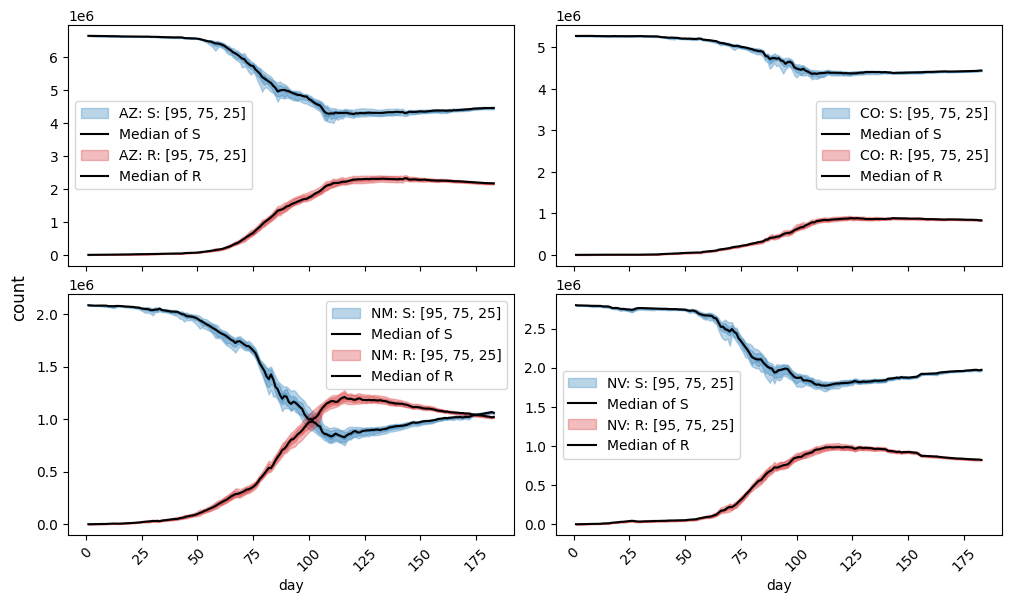

In [21]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline

plotter = PlotRendererPipeline(particle_filter_output)
geo = rume.scope.select.all()
time = rume.time_frame.select.all()
quantity = rume.ipm.select.compartments("S", "R")
plotter.quantiles(
    geo,
    time,
    quantity,
    ncols=2,
    legend="on",
    line_kwargs=[{"color": "black"}],
    fill_kwargs=[
        {"color": "tab:blue", "alpha": 0.3},
        {"color": "tab:red", "alpha": 0.3},
    ],  # Applies to the infill color
    credible_intervals=[95, 75, 25],
)

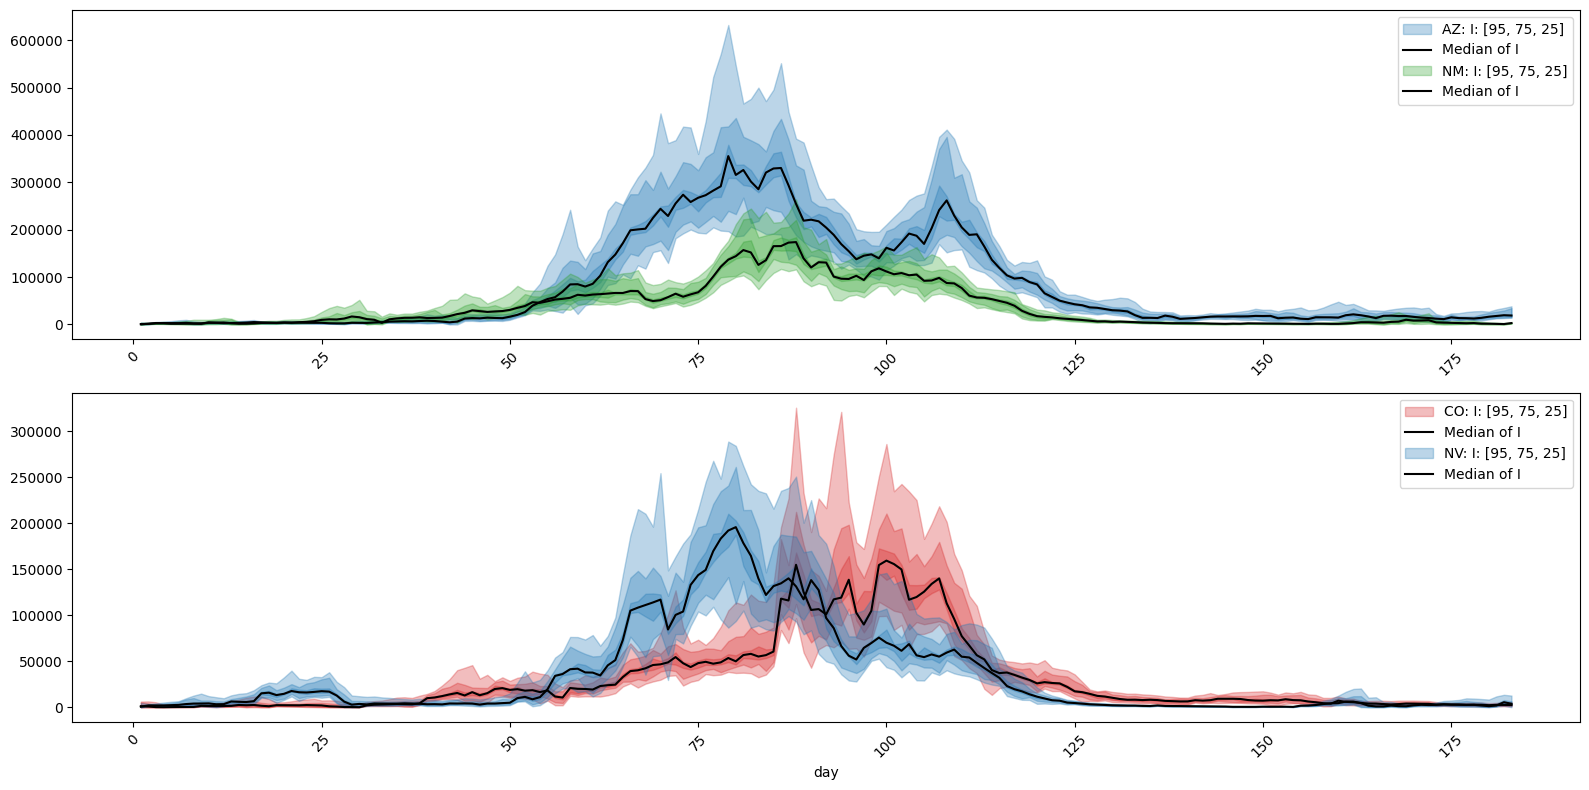

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 8))
geo = rume.scope.select.all()
time = rume.time_frame.select.all()
quantity = rume.ipm.select.compartments("I")

plotter.quantiles_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    legend="on",
    kwarg_type="geo",
    line_kwargs=[{"color": "black"}],
    fill_kwargs=[
        {"color": "tab:blue", "alpha": 0.3},
        {"color": "tab:red", "alpha": 0.3},
        {"color": "tab:green", "alpha": 0.3},
    ],
    credible_intervals=[95, 75, 25],
)

fig.tight_layout()
plt.show()

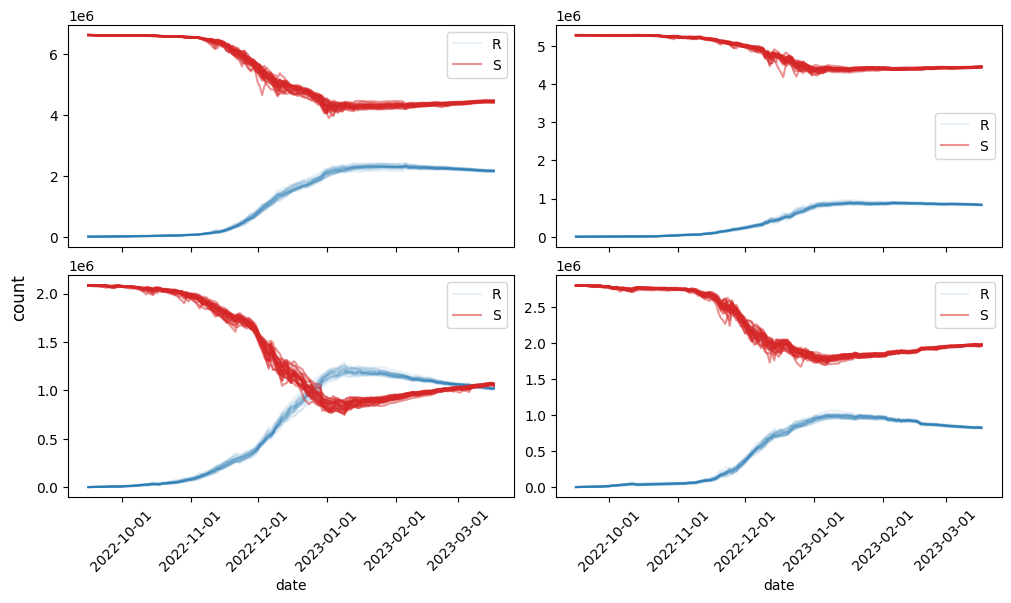

In [23]:
geo = rume.scope.select.all()
time = rume.time_frame.select.all()
quantity = rume.ipm.select.compartments('S','R')
realization = particle_filter_output.select.all()

plotter.spaghetti(
    realization,
    geo,
    time,
    quantity,
    ncols = 2,
    time_format="date",
    qline_kwargs=[{"color": "tab:blue","alpha":0.1},{"color":"tab:red","alpha":0.5}],
)

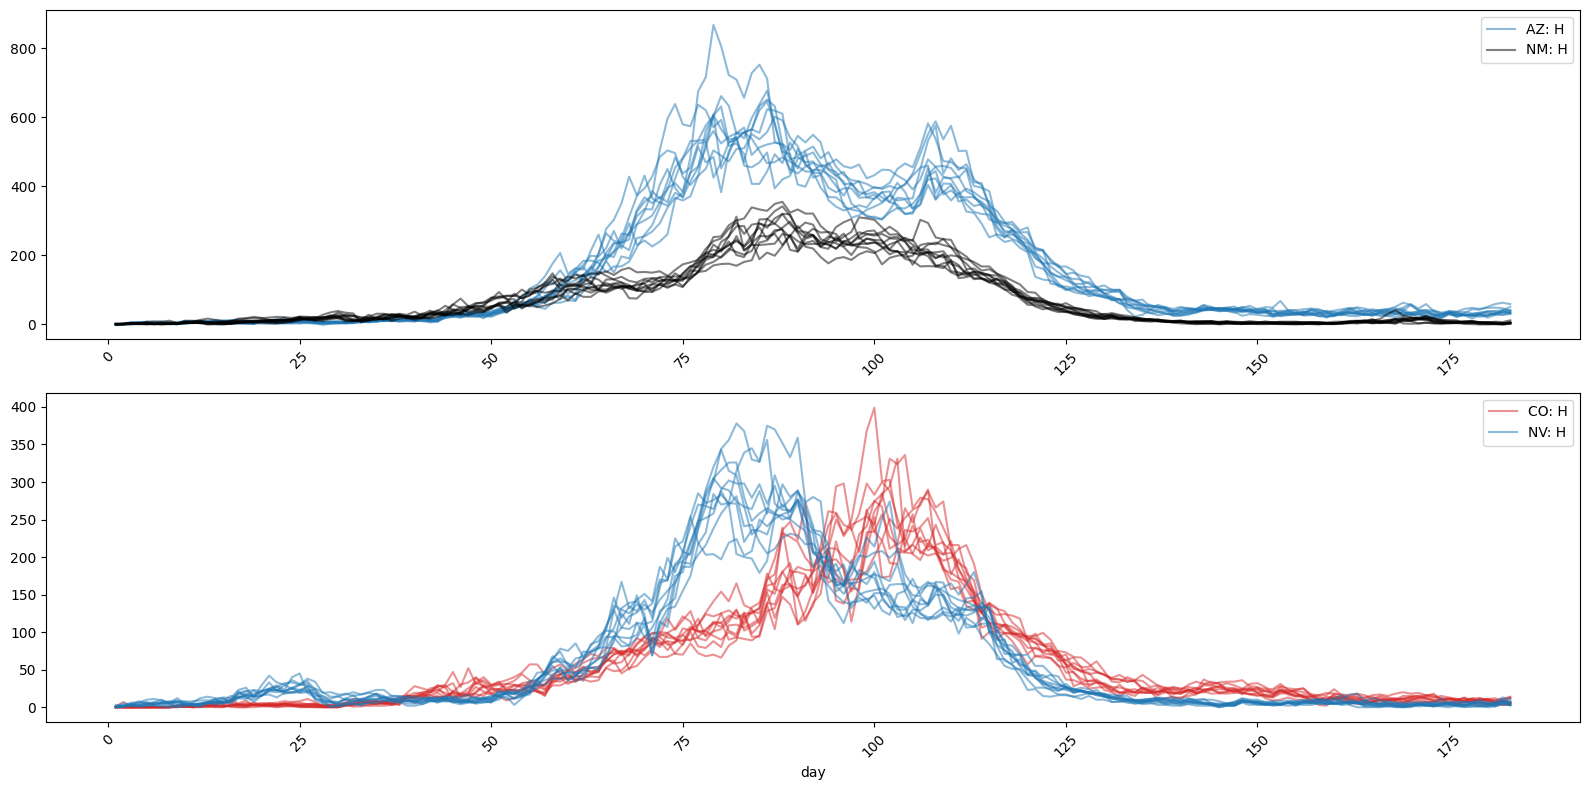

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 8))
quantity = rume.ipm.select.compartments("H")
geo = rume.scope.select.all()
time = rume.time_frame.select.all()

sample_rng = np.random.default_rng(1)

realization = particle_filter_output.select.sample(rng = sample_rng,size = 10)

plotter.spaghetti_plt(
    np.array([axes]),
    realization,
    geo,
    time,
    quantity,
    legend="on",
    kwarg_type="geo",
    line_kwargs=[
        {"color": "tab:blue", "alpha": 0.5},
        {"color": "tab:red", "alpha": 0.5},
        {"color": "black", "alpha": 0.5}
    ],
)

fig.tight_layout()
plt.show()

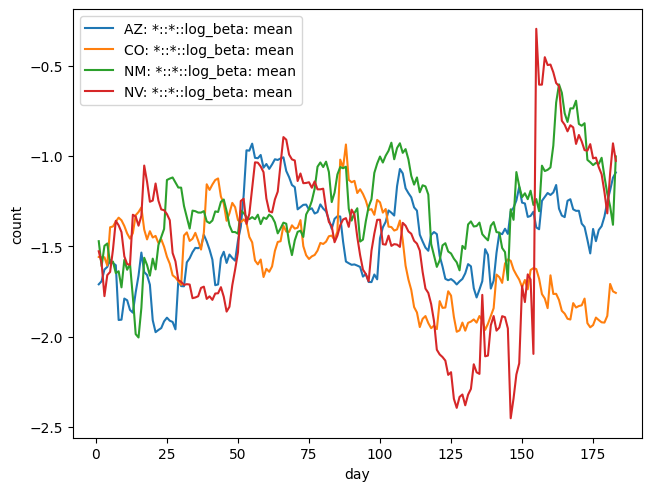

In [25]:
quantity = particle_filter_output.param_select.by_name("log_beta")
realization = particle_filter_output.select.all().agg(['mean'])
geo = rume.scope.select.all()
time = rume.time_frame.select.all()
plotter.line(realization,geo,time,quantity)

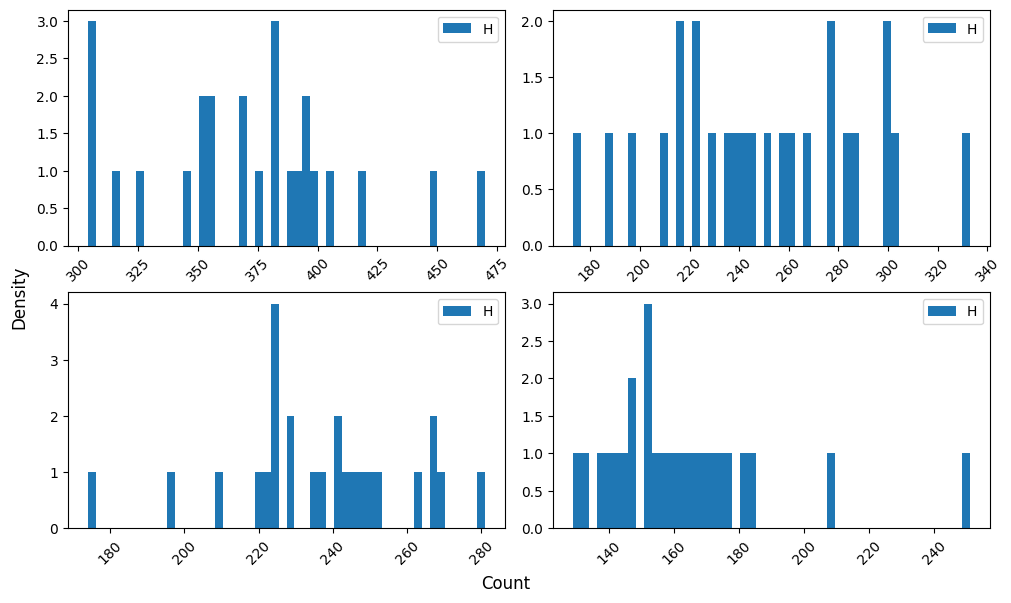

In [26]:
quantity = rume.ipm.select.compartments("H")
geo = rume.scope.select.all()
time = rume.time_frame.select.days(100, 100)

plotter.histogram(geo, time, quantity, hist_kwargs=[{"bins": 50}],ncols=2, legend="on")


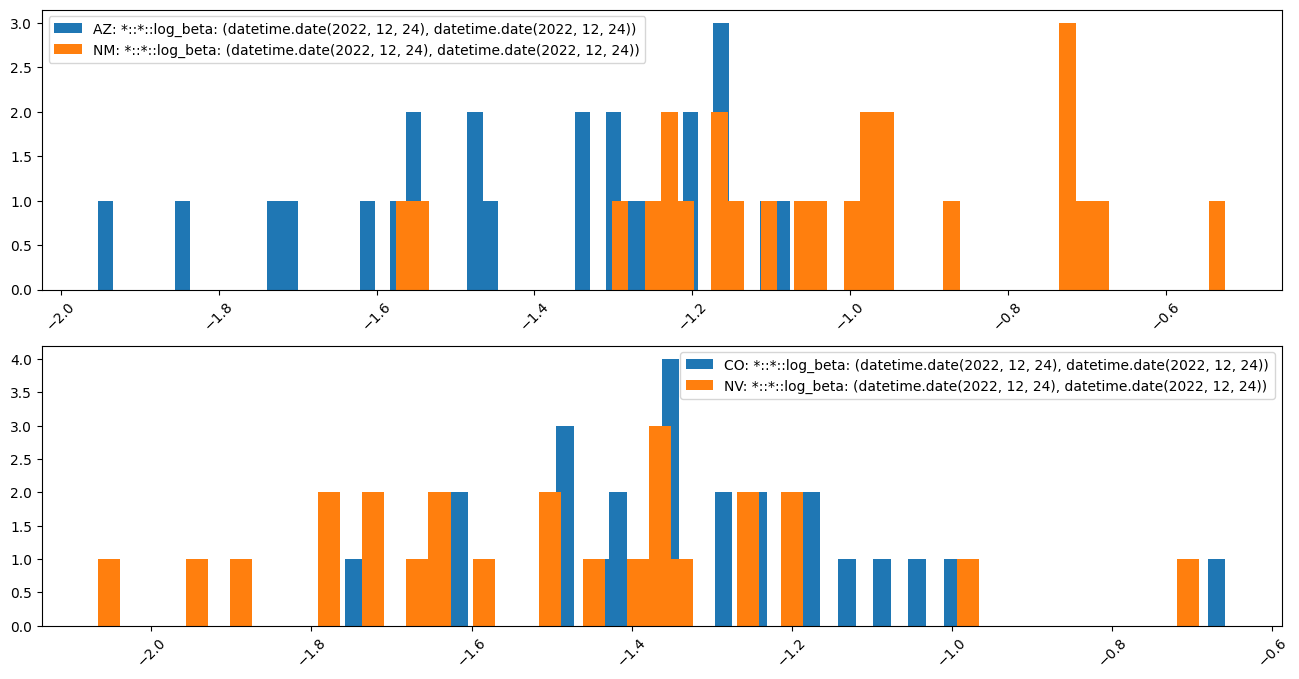

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 8))
quantity = particle_filter_output.param_select.by_name("log_beta")
geo = rume.scope.select.all()
time = rume.time_frame.select.days(100, 100)

plotter.histogram_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    hist_kwargs=[{"bins": 50}],
    legend="on",
    kwarg_type="quantity",
)
plt.show()